# Super Store Sales Analysis

##1. Business Problem
The objective of this project is to analyze Superstore sales data and identify key factors affecting sales and profitability to support business decisions.

In [27]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
#load the file
df=pd.read_csv("cleaned superstore dataset.csv")
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin %
0,CA-2019-103800,2019-01-03,2019-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,33.75
1,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,36.25
2,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,-23.75
3,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,-155.00
4,CA-2019-141817,2019-01-05,2019-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,...,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,25.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9988,CA-2022-156720,2022-12-30,2023-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048,-20.00
9989,CA-2022-143259,2022-12-30,2023-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910,37.50
9990,CA-2022-143259,2022-12-30,2023-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,...,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279,3.00
9991,CA-2022-115427,2022-12-30,2023-01-03,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,California,...,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188,32.50


##2. Data Understanding
The dataset contains information about orders, sales, profit, discount, categories, and regions of a retail superstore.

In [29]:
#check each column's type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order ID         9993 non-null   object 
 1   Order Date       9993 non-null   object 
 2   Ship Date        9993 non-null   object 
 3   Ship Mode        9993 non-null   object 
 4   Customer ID      9993 non-null   object 
 5   Customer Name    9993 non-null   object 
 6   Segment          9993 non-null   object 
 7   Country          9993 non-null   object 
 8   City             9993 non-null   object 
 9   State            9993 non-null   object 
 10  Postal Code      9993 non-null   int64  
 11  Region           9993 non-null   object 
 12  Product ID       9993 non-null   object 
 13  Category         9993 non-null   object 
 14  Sub-Category     9993 non-null   object 
 15  Product Name     9993 non-null   object 
 16  Sales            9993 non-null   float64
 17  Quantity      

## 3. Data Cleaning & Preprocessing


In [30]:
# convert the 'Date' column to datetime format
df['Order Date']= pd.to_datetime(df['Order Date'])
df['Ship Date']= pd.to_datetime(df['Ship Date'])

# Check the format of 'Date' column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         9993 non-null   object        
 1   Order Date       9993 non-null   datetime64[ns]
 2   Ship Date        9993 non-null   datetime64[ns]
 3   Ship Mode        9993 non-null   object        
 4   Customer ID      9993 non-null   object        
 5   Customer Name    9993 non-null   object        
 6   Segment          9993 non-null   object        
 7   Country          9993 non-null   object        
 8   City             9993 non-null   object        
 9   State            9993 non-null   object        
 10  Postal Code      9993 non-null   int64         
 11  Region           9993 non-null   object        
 12  Product ID       9993 non-null   object        
 13  Category         9993 non-null   object        
 14  Sub-Category     9993 non-null   object 

In [31]:
#sort values by Order Date column
df=df.sort_values(by="Order Date")
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin %
0,CA-2019-103800,2019-01-03,2019-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,33.75
1,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,36.25
2,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,-23.75
3,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,-155.00
4,CA-2019-141817,2019-01-05,2019-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,...,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,25.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,CA-2022-126221,2022-12-30,2023-01-03,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,...,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300,2,0.0,56.5110,27.00
9988,CA-2022-156720,2022-12-30,2023-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048,-20.00
9989,CA-2022-143259,2022-12-30,2023-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910,37.50
9990,CA-2022-143259,2022-12-30,2023-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,...,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279,3.00


In [32]:
# drop rows where ship date is earlier than order date
df = df[df['Ship Date'] >= df['Order Date']]
df

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin %
0,CA-2019-103800,2019-01-03,2019-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,33.75
1,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,36.25
2,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,-23.75
3,CA-2019-112326,2019-01-04,2019-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,-155.00
4,CA-2019-141817,2019-01-05,2019-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,...,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,25.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9987,CA-2022-126221,2022-12-30,2023-01-03,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,Indiana,...,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300,2,0.0,56.5110,27.00
9988,CA-2022-156720,2022-12-30,2023-01-03,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,Colorado,...,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048,-20.00
9989,CA-2022-143259,2022-12-30,2023-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,...,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910,37.50
9990,CA-2022-143259,2022-12-30,2023-01-03,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,New York,...,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279,3.00


In [33]:
#find the column with the number of missing values
df.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0
State,0


In [34]:
#find the number of duplicates
df.duplicated().sum()

np.int64(0)

In [35]:
# Show the duplicated rows
df[df.duplicated(keep = 'last')]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin %


In [36]:
# double check the duplicated rows
df[df.duplicated(keep = 'first')]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit Margin %


In [37]:
#remove duplicates
df=df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9992
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order ID         9993 non-null   object        
 1   Order Date       9993 non-null   datetime64[ns]
 2   Ship Date        9993 non-null   datetime64[ns]
 3   Ship Mode        9993 non-null   object        
 4   Customer ID      9993 non-null   object        
 5   Customer Name    9993 non-null   object        
 6   Segment          9993 non-null   object        
 7   Country          9993 non-null   object        
 8   City             9993 non-null   object        
 9   State            9993 non-null   object        
 10  Postal Code      9993 non-null   int64         
 11  Region           9993 non-null   object        
 12  Product ID       9993 non-null   object        
 13  Category         9993 non-null   object        
 14  Sub-Category     9993 non-null   object      

##EDA


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns


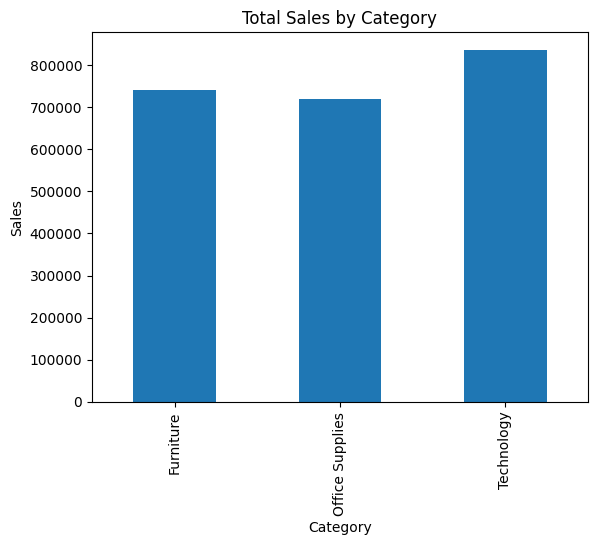

In [39]:
# This graph compares total sales across different product categories
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()


**Insight:** Technology category contributes the highest sales, indicating strong demand for tech products.


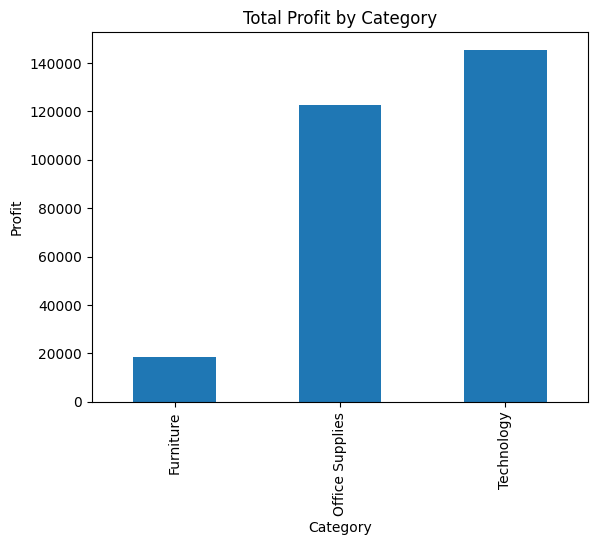

In [40]:
# This graph shows which product category generates the highest profit
df.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()


**Insight:** Although Furniture has good sales, its profit is significantly lower compared to Technology.


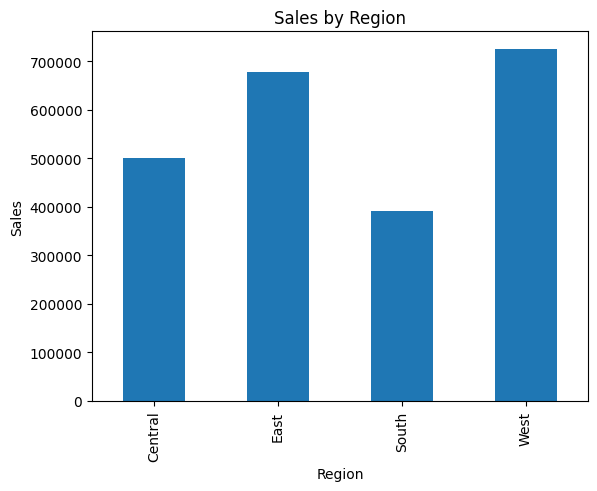

In [41]:
# This graph displays sales performance across different regions
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()


**Insight:** West region performs best in terms of sales, while South region shows comparatively lower performance.


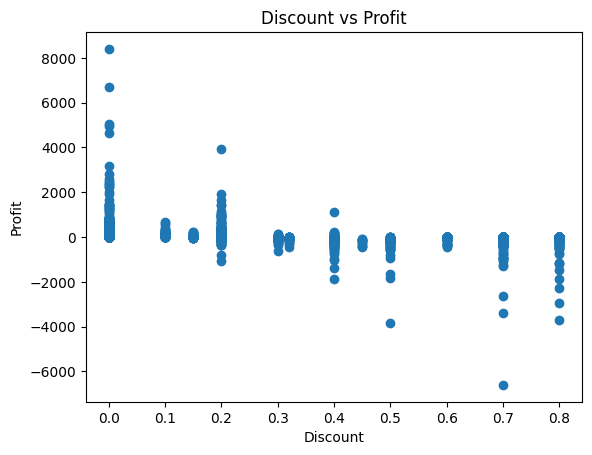

In [42]:
# This scatter plot illustrates the impact of discounts on profit
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


**Insight:** Higher discounts are generally associated with lower or negative profit, indicating margin loss.


## Final Business Summary

- Technology category is the most profitable and should be prioritized.
- Excessive discounts negatively impact profitability.
- Regional performance varies significantly, with the West region leading in sales.
- Data-driven decisions can help optimize pricing and inventory strategies.
